In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn joblib


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# --- 1. Data Understanding ---

# Load Dataset
try:
    # Ganti 'data-bank.csv' dengan path file Anda jika berbeda
    df = pd.read_csv('data-bank.csv')
except FileNotFoundError:
    print("Error: Pastikan file 'data-bank.csv' berada di direktori yang sama.")
    exit()

# Rename columns to remove leading spaces for easier access
df.columns = df.columns.str.strip()
target_variable = 'Bankrupt?'

print("--- 5 Baris Pertama Data ---")
print(df.head())

print("\n--- Informasi Umum Data ---")
df.info()

print("\n--- Statistik Deskriptif ---")
print(df.describe())

print(f"\nTarget Variable: {target_variable}")
print("Distribusi Target Variable:")
print(df[target_variable].value_counts())
print(f"Persentase Kebangkrutan (1): {df[target_variable].mean() * 100:.2f}%")

# Simpan data ke file sementara untuk digunakan di fase berikutnya
df.to_csv('processed_data.csv', index=False)


--- 5 Baris Pertama Data ---
   Bankrupt?  ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594         
1          1                                           0.464291         
2          1                                           0.426071         
3          1                                           0.399844         
4          1                                           0.465022         

   ROA(A) before interest and % after tax  \
0                                0.424389   
1                                0.538214   
2                                0.499019   
3                                0.451265   
4                                0.538432   

   ROA(B) before interest and depreciation after tax  Operating Gross Margin  \
0                                           0.405750                0.601457   
1                                           0.516730                0.610235   
2                    

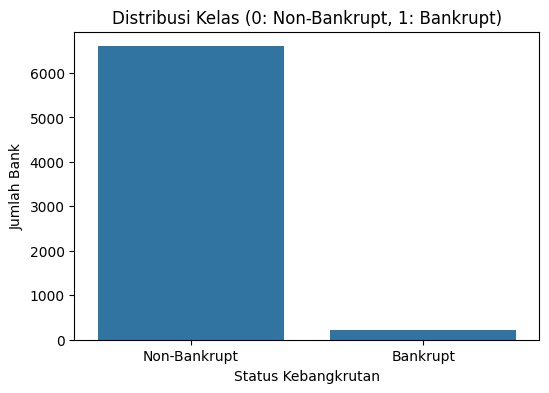

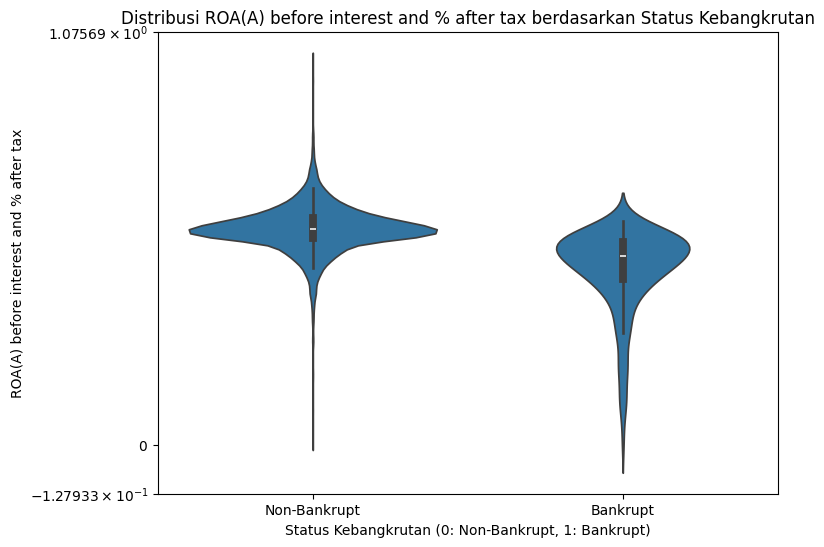

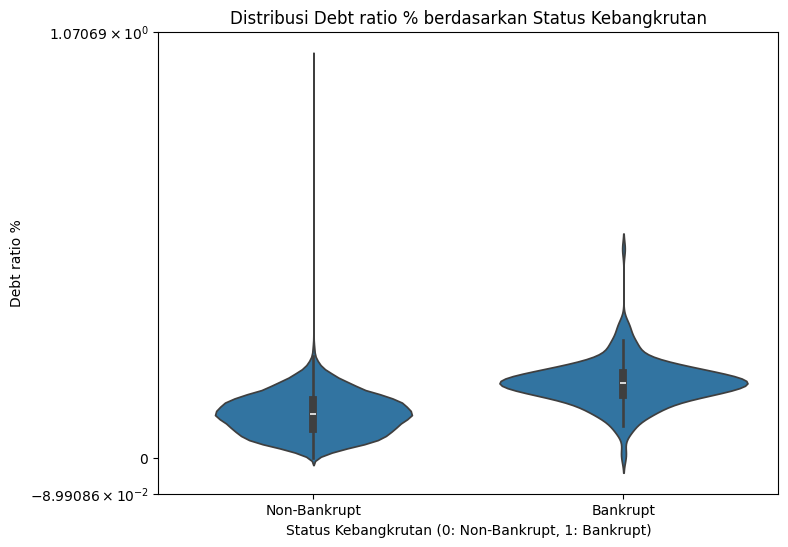

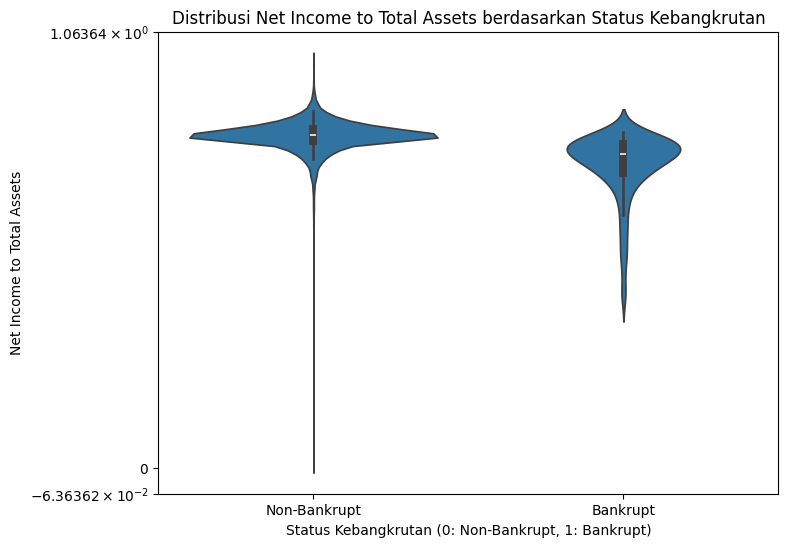


--- Pemeriksaan Nilai Inf (Infinity) ---
Tidak ada nilai Inf yang terdeteksi.


In [4]:
# --- 2. Exploratory Data Analysis (EDA) ---

df = pd.read_csv('processed_data.csv')
df.columns = df.columns.str.strip()
target_variable = 'Bankrupt?'

# 2.1 Visualisasi Ketidakseimbangan Kelas (Class Imbalance)
plt.figure(figsize=(6, 4))
sns.countplot(x=target_variable, data=df)
plt.title('Distribusi Kelas (0: Non-Bankrupt, 1: Bankrupt)')
plt.xlabel('Status Kebangkrutan')
plt.ylabel('Jumlah Bank')
plt.xticks([0, 1], ['Non-Bankrupt', 'Bankrupt'])
plt.show() # Gunakan plt.show() di Jupyter Notebook

# 2.2 Visualisasi Hubungan 2 Variabel dengan Target
key_indicators = [
    'ROA(A) before interest and % after tax', 
    'Debt ratio %', 
    'Net Income to Total Assets'
]

for indicator in key_indicators:
    plt.figure(figsize=(8, 6))
    df_plot = df.copy()
    # Mengganti nilai 0 dengan nilai yang sangat kecil untuk log transformation
    df_plot[indicator] = df_plot[indicator].replace(0, 1e-6)
    
    sns.violinplot(x=target_variable, y=indicator, data=df_plot)
    plt.title(f'Distribusi {indicator} berdasarkan Status Kebangkrutan')
    plt.xlabel('Status Kebangkrutan (0: Non-Bankrupt, 1: Bankrupt)')
    plt.ylabel(indicator)
    plt.xticks([0, 1], ['Non-Bankrupt', 'Bankrupt'])
    plt.yscale('symlog') # Menggunakan symlog untuk menangani nilai negatif dan positif dengan rentang besar
    plt.show() # Gunakan plt.show() di Jupyter Notebook

# 2.3 Identifikasi Kolom dengan Nilai NaN/Inf
print("\n--- Pemeriksaan Nilai Inf (Infinity) ---")
is_inf = df.isin([np.inf, -np.inf]).sum()
inf_cols = is_inf[is_inf > 0]
if not inf_cols.empty:
    print("Kolom dengan nilai Inf:")
    print(inf_cols.to_markdown(numalign="left", stralign="left"))
else:
    print("Tidak ada nilai Inf yang terdeteksi.")


In [5]:
# --- 3. Data Preparation ---

df = pd.read_csv('processed_data.csv')
df.columns = df.columns.str.strip()
target_variable = 'Bankrupt?'

# 3.1 Data Cleaning (Handling NaN/Inf)
# Ganti nilai Inf dengan NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Isi NaN dengan nilai median dari kolom tersebut
df.fillna(df.median(), inplace=True)

# 3.2 Pemisahan Fitur dan Target
X = df.drop(target_variable, axis=1)
y = df[target_variable]

# 3.3 Pembagian Data (Training dan Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("\nData telah dibagi menjadi data training dan testing.")
print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")

# 3.4 Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Fitur telah di-scaling menggunakan StandardScaler.")

# 3.5 Penanganan Ketidakseimbangan Kelas (Class Imbalance)
# Jawaban: Data **TIDAK** seimbang (hanya 3.23% kasus kebangkrutan).
# Penanganan: Menggunakan **SMOTE** (Synthetic Minority Over-sampling Technique) pada data training.
print("\n--- Penanganan Ketidakseimbangan Kelas (SMOTE) ---")
print("Distribusi kelas sebelum SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nDistribusi kelas setelah SMOTE:")
print(y_train_smote.value_counts())

# Simpan data yang sudah diproses untuk fase berikutnya
np.save('X_train_smote.npy', X_train_smote)
np.save('y_train_smote.npy', y_train_smote)
np.save('X_test_scaled.npy', X_test_scaled)
np.save('y_test.npy', y_test)
print("Data training dan testing yang sudah diproses telah disimpan.")



Data telah dibagi menjadi data training dan testing.
Jumlah data training: 5455
Jumlah data testing: 1364
Fitur telah di-scaling menggunakan StandardScaler.

--- Penanganan Ketidakseimbangan Kelas (SMOTE) ---
Distribusi kelas sebelum SMOTE:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64

Distribusi kelas setelah SMOTE:
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64
Data training dan testing yang sudah diproses telah disimpan.


In [6]:
# --- 4. Modelling ---

X_train_smote = np.load('X_train_smote.npy')
y_train_smote = np.load('y_train_smote.npy')
X_test_scaled = np.load('X_test_scaled.npy')
y_test = np.load('y_test.npy')

models = {}

# 4.1 Decision Tree Classifier
print("\n--- Training Decision Tree Classifier ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_smote, y_train_smote)
models['Decision Tree'] = dt_model
print("Decision Tree model selesai dilatih.")

# 4.2 Random Forest Classifier
print("\n--- Training Random Forest Classifier ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
models['Random Forest'] = rf_model
print("Random Forest model selesai dilatih.")

# 4.3 Artificial Neural Network (MLP Classifier)
print("\n--- Training MLP Classifier ---")
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_model.fit(X_train_smote, y_train_smote)
models['MLP'] = mlp_model
print("MLP model selesai dilatih.")

# Simpan model untuk fase evaluasi
joblib.dump(models, 'trained_models.pkl')
print("Semua model telah disimpan ke 'trained_models.pkl'.")



--- Training Decision Tree Classifier ---
Decision Tree model selesai dilatih.

--- Training Random Forest Classifier ---
Random Forest model selesai dilatih.

--- Training MLP Classifier ---
MLP model selesai dilatih.
Semua model telah disimpan ke 'trained_models.pkl'.


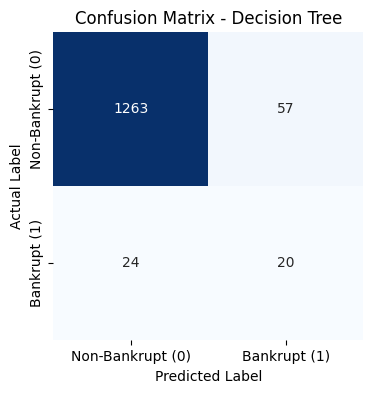


--- Classification Report untuk Decision Tree ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1320
           1       0.26      0.45      0.33        44

    accuracy                           0.94      1364
   macro avg       0.62      0.71      0.65      1364
weighted avg       0.96      0.94      0.95      1364



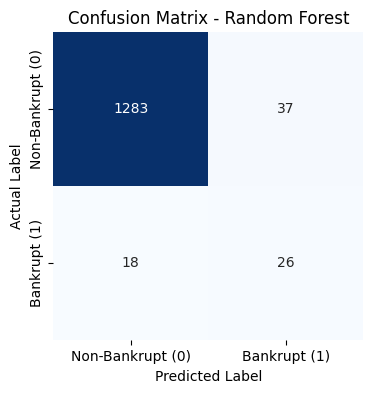


--- Classification Report untuk Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.41      0.59      0.49        44

    accuracy                           0.96      1364
   macro avg       0.70      0.78      0.73      1364
weighted avg       0.97      0.96      0.96      1364



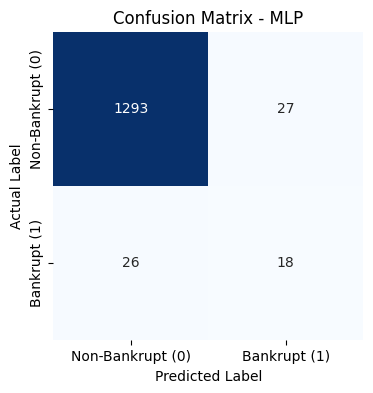


--- Classification Report untuk MLP ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.40      0.41      0.40        44

    accuracy                           0.96      1364
   macro avg       0.69      0.69      0.69      1364
weighted avg       0.96      0.96      0.96      1364


--- Perbandingan Kinerja Model ---
| Model         | Accuracy   | Precision (Bankrupt)   | Recall (Bankrupt)   | F1-Score (Bankrupt)   | Support (Bankrupt)   |
|:--------------|:-----------|:-----------------------|:--------------------|:----------------------|:---------------------|
| Decision Tree | 0.940616   | 0.25974                | 0.454545            | 0.330579              | 44                   |
| Random Forest | 0.959677   | 0.412698               | 0.590909            | 0.485981              | 44                   |
| MLP           | 0.961144   | 0.4                    | 0.409091            | 0.404494          

In [7]:
# --- 5. Evaluation ---

X_test_scaled = np.load('X_test_scaled.npy')
y_test = np.load('y_test.npy')
models = joblib.load('trained_models.pkl')

results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Non-Bankrupt (0)', 'Bankrupt (1)'],
                yticklabels=['Non-Bankrupt (0)', 'Bankrupt (1)'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show() # Gunakan plt.show() di Jupyter Notebook
    
    # Classification Report
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision (Bankrupt)': report['1']['precision'],
        'Recall (Bankrupt)': report['1']['recall'],
        'F1-Score (Bankrupt)': report['1']['f1-score'],
        'Support (Bankrupt)': report['1']['support']
    })
    
    print(f"\n--- Classification Report untuk {name} ---")
    print(classification_report(y_test, y_pred))

# Perbandingan Model
results_df = pd.DataFrame(results)
print("\n--- Perbandingan Kinerja Model ---")
print(results_df.to_markdown(index=False, numalign="left", stralign="left"))

# Penentuan Model Terbaik
# Dalam kasus prediksi kebangkrutan, **Recall** untuk kelas minoritas (Bankrupt/1) sangat penting untuk meminimalkan False Negatives (Bank yang bangkrut diprediksi tidak bangkrut).
best_model = results_df.loc[results_df['Recall (Bankrupt)'].idxmax()]
print("\nModel yang paling sesuai (dengan Recall tertinggi untuk kelas Bankrupt):")
print(best_model.to_markdown(numalign="left", stralign="left"))
